# 04 · Generative versus discriminative attribution, and the ablations

The centre of the project. Everything is evaluated on the **same
work-disjoint test split**, so the rows of the final table are comparable.

**Generative.** One n-gram language model per author, fit only on that
author's training text, smoothed with interpolated Kneser–Ney. A passage goes
to whichever author's model assigns it the lowest perplexity. The model never
sees the other authors — it learns what this author's text looks like, not
how they differ.

**Discriminative.** All authors' features go into one classifier trained to
tell them apart: a linear SVM over stylometric and/or embedding features, and
a fine-tuned BanglaBERT.

The ablations answer the proposal's two comparison questions: which feature
families matter, and pretrained versus from-scratch embeddings.

In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import numpy as np, pandas as pd
import matplotlib
import matplotlib.pyplot as plt

# Bengali glyphs need a font that has them; fall back silently if absent.
for _f in ("Nirmala UI", "Vrinda", "Shonar Bangla", "Noto Sans Bengali"):
    try:
        matplotlib.font_manager.findfont(_f, fallback_to_default=False)
        plt.rcParams["font.family"] = _f
        break
    except Exception:
        continue
plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight",
                     "axes.grid": True, "grid.alpha": 0.25})
pd.set_option("display.width", 160, "display.max_columns", 60)

from banglastylo import config
print("project root:", ROOT)

project root: E:\NLP Project\Bangla-author-fingerprinting


In [2]:
from banglastylo import corpus, splits, evaluate, embeddings
from banglastylo.models import (GenerativeAttributor, build_svm_pipeline,
                                build_svm, BertClassifier)

passages = corpus.load_passages()
split = splits.load(passages)
Xtr, ytr = splits.xy(split.train)
Xva, yva = splits.xy(split.val)
Xte, yte = splits.xy(split.test)

n_authors = len(set(ytr))
chance = 1 / n_authors
results = evaluate.ResultTable(chance=chance)
print(f"{n_authors} authors · train {len(Xtr)} · val {len(Xva)} · test {len(Xte)}")
print(f"chance accuracy = {chance:.4f}")

5 authors · train 1821 · val 422 · test 712
chance accuracy = 0.2000


## 4.1 Generative: per-author language models

Character models first. Bangla is morphologically rich and its inflection is
suffixal, so a character model sees inside the word — it picks up the
register difference between করিয়াছিলেন and করেছিলেন without either form
having been seen whole.

In [3]:
gen_char = GenerativeAttributor(level="char", order=config.CHAR_LM_ORDER)
gen_char.fit(Xtr, ytr)
pred_gen_char = gen_char.predict(Xte)
res_gen_char = results.add(
    f"Generative char-{config.CHAR_LM_ORDER}-gram LM", "characters",
    yte, pred_gen_char, "per-author Kneser-Ney LM, lowest perplexity wins")

  [char-5gram] abanindranath     369 passages,     130 symbol types


  [char-5gram] bankim            365 passages,     131 symbol types


  [char-5gram] sarat             377 passages,      76 symbol types


  [char-5gram] tagore            355 passages,     125 symbol types


  [char-5gram] vidyasagar        355 passages,      90 symbol types


  Generative char-5-gram LM                    acc=0.8343 [0.806, 0.861]  macroF1=0.8431


In [4]:
gen_word = GenerativeAttributor(level="word", order=config.WORD_LM_ORDER)
gen_word.fit(Xtr, ytr)
pred_gen_word = gen_word.predict(Xte)
res_gen_word = results.add(
    f"Generative word-{config.WORD_LM_ORDER}-gram LM", "words",
    yte, pred_gen_word, "per-author Kneser-Ney LM, lowest perplexity wins")

  [word-3gram] abanindranath     369 passages,  16,470 symbol types


  [word-3gram] bankim            365 passages,  15,056 symbol types


  [word-3gram] sarat             377 passages,  13,463 symbol types


  [word-3gram] tagore            355 passages,  18,874 symbol types


  [word-3gram] vidyasagar        355 passages,  12,347 symbol types


  Generative word-3-gram LM                    acc=0.7683 [0.736, 0.799]  macroF1=0.7668


### The perplexity table itself

The generative decision is a comparison of perplexities, so it is worth
looking at the actual numbers for a handful of test passages rather than only
the argmax.

In [5]:
sample = list(range(0, len(Xte), max(len(Xte) // 6, 1)))[:6]
ppl = gen_char.perplexity_table([Xte[i] for i in sample])
ppl_df = pd.DataFrame(ppl, columns=[config.AUTHORS[a]["short"]
                                    for a in gen_char.classes_])
ppl_df.insert(0, "true author",
              [config.AUTHORS[yte[i]]["short"] for i in sample])
ppl_df.style.background_gradient(cmap="Blues_r", axis=1,
                                 subset=ppl_df.columns[1:])

,true author,A. Tagore,Bankim,Sarat Ch.,R. Tagore,Vidyasagar
0,A. Tagore,5.728382,12.654609,10.436213,12.547737,34.279514
1,A. Tagore,7.938950,14.687929,12.321061,13.299320,34.603557
2,Bankim,9.018707,4.905902,7.867852,6.097261,7.761394
3,Sarat Ch.,9.715683,6.570672,5.760633,6.037506,10.436197
4,R. Tagore,15.179928,7.358761,10.048622,6.997788,8.154380
5,Vidyasagar,13.507935,8.048135,9.001131,6.651629,5.309988


## 4.2 Discriminative: linear SVM ablations

Each row isolates one feature family or one combination, so the table answers
"what is doing the work?" rather than only "how well does it do?".

In [6]:
svm_ablations = {
    "SVM · function words only":        ("funcword",),
    "SVM · structural only":            ("structural",),
    "SVM · POS n-grams only":           ("posngram",),
    "SVM · char n-grams only":          ("charngram",),
    "SVM · funcword + structural":      ("funcword", "structural"),
    "SVM · all stylometric":            ("funcword", "structural",
                                         "charngram", "posngram"),
}

pipelines = {}
for name, fams in svm_ablations.items():
    pipe = build_svm_pipeline(families=fams)
    pipe.fit(Xtr, ytr)
    pipelines[name] = pipe
    results.add(name, "+".join(fams), yte, pipe.predict(Xte))

  SVM · function words only                    acc=0.7261 [0.694, 0.758]  macroF1=0.7196


  SVM · structural only                        acc=0.8006 [0.770, 0.829]  macroF1=0.7994


  SVM · POS n-grams only                       acc=0.6110 [0.574, 0.646]  macroF1=0.6023


  SVM · char n-grams only                      acc=0.7781 [0.746, 0.808]  macroF1=0.7726


  SVM · funcword + structural                  acc=0.7978 [0.768, 0.826]  macroF1=0.7982


  SVM · all stylometric                        acc=0.7949 [0.765, 0.824]  macroF1=0.7903


## 4.3 Discriminative: embedding features

The proposal's pretrained-versus-from-scratch comparison, held under
otherwise identical conditions — same classifier, same split, same
evaluation.

In [7]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

V = np.load(config.MODELS / "w2v_vectors.npz")
B = np.load(config.MODELS / "banglabert_vectors.npz")

embedding_sets = {
    "SVM · scratch w2v (SIF pooled)":  (V["train_sif"],  V["test_sif"]),
    "SVM · scratch w2v (mean pooled)": (V["train_mean"], V["test_mean"]),
    "SVM · BanglaBERT frozen":         (B["train"],      B["test"]),
}

emb_models = {}
for name, (Etr, Ete) in embedding_sets.items():
    clf = make_pipeline(StandardScaler(), build_svm())
    clf.fit(Etr, ytr)
    emb_models[name] = clf
    results.add(name, "embeddings", yte, clf.predict(Ete))

  SVM · scratch w2v (SIF pooled)               acc=0.7669 [0.736, 0.796]  macroF1=0.7559


  SVM · scratch w2v (mean pooled)              acc=0.7542 [0.723, 0.785]  macroF1=0.7405


  SVM · BanglaBERT frozen                      acc=0.7739 [0.744, 0.805]  macroF1=0.7531


### Stylometric + embedding, combined

The proposal's headline discriminative configuration: concatenate the
stylometric features with the embedding features and feed the lot to one
SVM.

In [8]:
from scipy import sparse
from sklearn.preprocessing import MaxAbsScaler
from banglastylo.stylometry import StylometricFeatures

feat = StylometricFeatures(("funcword", "structural", "charngram", "posngram"))
feat.fit(Xtr)
Str, Ste = feat.transform(Xtr), feat.transform(Xte)

for label, (Etr, Ete) in [("scratch w2v", (V["train_mean"], V["test_mean"])),
                          ("BanglaBERT",  (B["train"],      B["test"]))]:
    scale = StandardScaler().fit(Etr)
    Ctr = sparse.hstack([Str, sparse.csr_matrix(scale.transform(Etr))]).tocsr()
    Cte = sparse.hstack([Ste, sparse.csr_matrix(scale.transform(Ete))]).tocsr()
    clf = make_pipeline(MaxAbsScaler(), build_svm())
    clf.fit(Ctr, ytr)
    results.add(f"SVM · stylometric + {label}", "combined", yte, clf.predict(Cte))

  SVM · stylometric + scratch w2v              acc=0.7907 [0.760, 0.820]  macroF1=0.7838


  SVM · stylometric + BanglaBERT               acc=0.8006 [0.771, 0.830]  macroF1=0.7836


## 4.4 Discriminative: fine-tuned BanglaBERT

The heaviest model in the comparison, and the one with the most outside
knowledge. Worth noting what it is being asked to do: BanglaBERT was
pretrained on *modern* Bangla, and this corpus is 19th- and early-20th-century
literary prose in a register the pretraining data barely contains.

In [9]:
import time

# Fine-tuning costs ~40 minutes on CPU, so a re-run reloads the checkpoint
# rather than paying for it again just to redraw a figure.
bert_dir = config.MODELS / "banglabert_finetuned"
if (bert_dir / "classes.txt").exists():
    bert = BertClassifier.load(bert_dir)
    print(f"loaded cached fine-tuned model from {bert_dir.name}")
else:
    t0 = time.time()
    bert = BertClassifier()
    bert.fit(Xtr, ytr, val=(Xva, yva))
    print(f"fine-tuning took {(time.time()-t0)/60:.1f} min on {bert.device}")
    bert.save(bert_dir)

pred_bert = bert.predict(Xte)
res_bert = results.add("Fine-tuned BanglaBERT", "pretrained transformer",
                       yte, pred_bert)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: csebuetnlp/banglabert
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors: reconstructing file:   0%|          |  0.00B /  443MB            

model.safetensors: downloading bytes:           |  0.00B            

    epoch 1 step 0/228 loss=1.6091


...

    epoch 2 step 225/228 loss=0.0810


  epoch 2/2 train_loss=0.0825  val_acc=0.8104


fine-tuning took 55.1 min on cpu


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Fine-tuned BanglaBERT                        acc=0.7753 [0.746, 0.803]  macroF1=0.7629


## 4.5 The results table

In [10]:
results.save("results_main")
df = results.frame().sort_values("accuracy", ascending=False)
tex = results.to_latex(
    "results_main",
    caption=("Closed-set authorship attribution on the held-out, work-disjoint "
             "test split. Intervals are 95\\% percentile bootstrap over test "
             "passages."),
    tex_label="tab:results")
df[["model", "family", "accuracy", "acc_lo", "acc_hi", "macro_f1"]]

wrote E:\NLP Project\Bangla-author-fingerprinting\artifacts\tables\results_main.csv


,model,family,accuracy,acc_lo,acc_hi,macro_f1
0,Generative char-5-gram LM,characters,0.834270,0.806180,0.860955,0.843056
3,SVM · structural only,structural,0.800562,0.769663,0.828652,0.799436
12,SVM · stylometric + BanglaBERT,combined,0.800562,0.771067,0.830091,0.783578
6,SVM · funcword + structural,funcword+structural,0.797753,0.768258,0.825843,0.798224
7,SVM · all stylometric,funcword+structural+charngram+posngram,0.794944,0.765414,0.824438,0.790307
11,SVM · stylometric + scratch w2v,combined,0.790730,0.759831,0.820225,0.783752
5,SVM · char n-grams only,charngram,0.778090,0.745787,0.807584,0.772615
13,Fine-tuned BanglaBERT,pretrained transformer,0.775281,0.745787,0.803406,0.762897
10,SVM · BanglaBERT frozen,embeddings,0.773876,0.744382,0.804775,0.753127
1,Generative word-3-gram LM,words,0.768258,0.735955,0.799157,0.766817


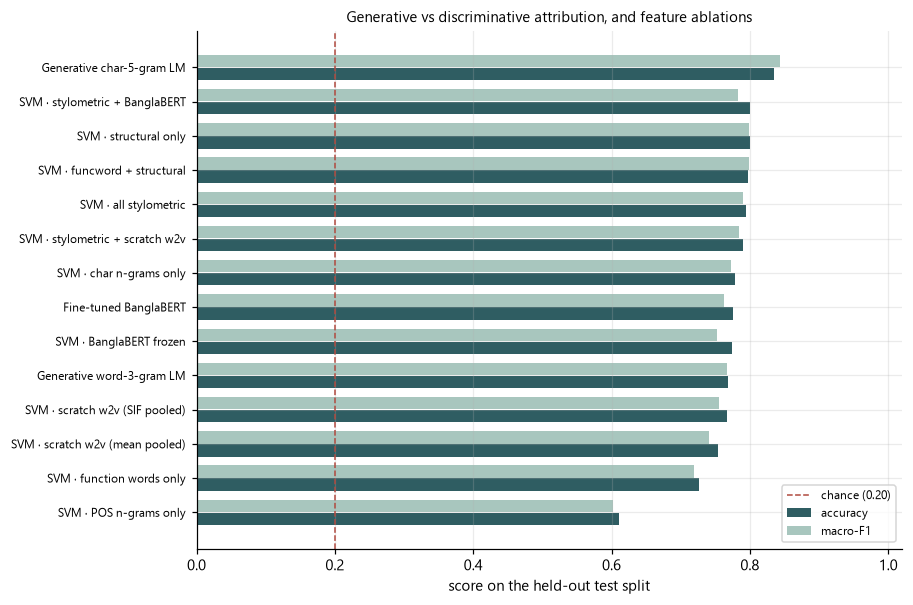

In [11]:
fig = evaluate.plot_ablation(
    results.frame(), path=config.FIGURES / "ablation.png",
    title="Generative vs discriminative attribution, and feature ablations")
plt.show()

## 4.6 Confusion analysis

The proposal asks specifically about confusion between *stylistically similar*
authors, so the confusion matrices matter more than the headline accuracy.

best model overall: Generative char-5-gram LM


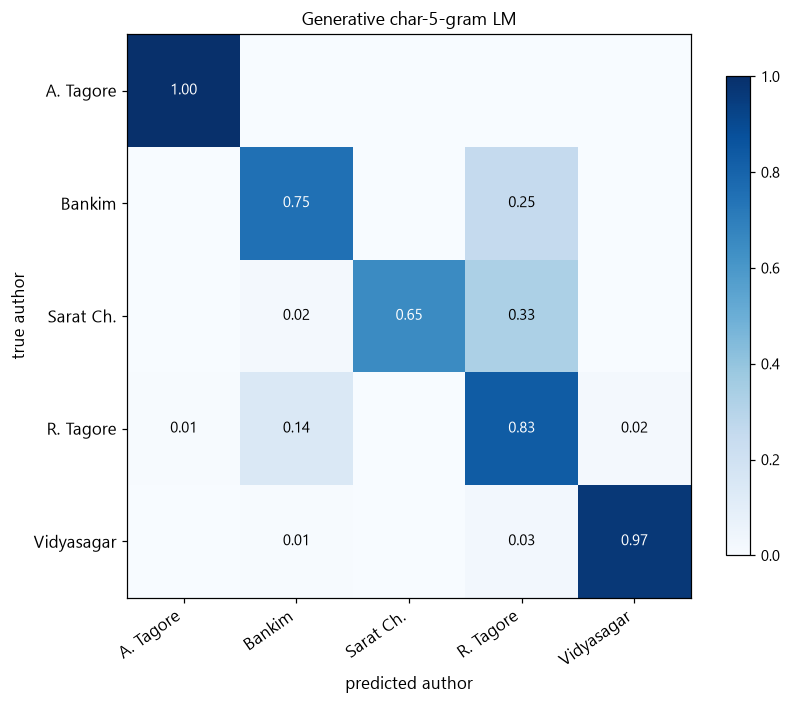

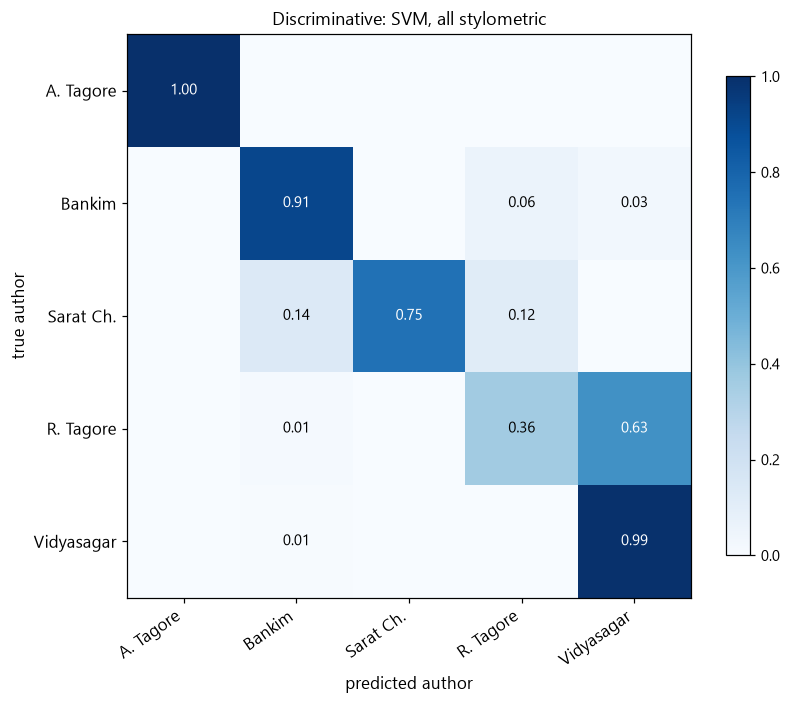

(best model is one of the two above; no third matrix drawn)


In [12]:
best_name = df.iloc[0]["model"]
print("best model overall:", best_name)

# One matrix per *paradigm*, not "best" and "generative" — those can be the
# same model, and two identical heatmaps side by side would say nothing.
fig = evaluate.plot_confusion(
    res_gen_char, f"Generative char-{config.CHAR_LM_ORDER}-gram LM",
    path=config.FIGURES / "confusion_generative.png")
plt.show()

disc_name = "SVM · all stylometric"
fig = evaluate.plot_confusion(results.full[disc_name],
                              "Discriminative: SVM, all stylometric",
                              path=config.FIGURES / "confusion_discriminative.png")
plt.show()

if best_name not in (disc_name, f"Generative char-{config.CHAR_LM_ORDER}-gram LM"):
    fig = evaluate.plot_confusion(results.full[best_name], best_name,
                                  path=config.FIGURES / "confusion_best.png")
    plt.show()
else:
    print("(best model is one of the two above; no third matrix drawn)")

In [13]:
print("most-confused author pairs\n")
shown = dict.fromkeys([best_name,
                       f"Generative char-{config.CHAR_LM_ORDER}-gram LM",
                       "SVM · all stylometric"])
for name in shown:
    print(name)
    for a, b, n, rate in evaluate.confusable_pairs(results.full[name], top_k=5):
        print(f"   {config.AUTHORS[a]['en']:32s} <-> "
              f"{config.AUTHORS[b]['en']:32s} {n:4d} errors  ({rate:.3f})")
    print()

most-confused author pairs

Generative char-5-gram LM
   Bankim Chandra Chattopadhyay     <-> Rabindranath Tagore                55 errors  (0.194)
   Sarat Chandra Chattopadhyay      <-> Rabindranath Tagore                51 errors  (0.169)
   Rabindranath Tagore              <-> Ishwar Chandra Vidyasagar           7 errors  (0.024)
   Bankim Chandra Chattopadhyay     <-> Sarat Chandra Chattopadhyay         3 errors  (0.010)
   Abanindranath Tagore             <-> Rabindranath Tagore                 1 errors  (0.004)

SVM · all stylometric
   Rabindranath Tagore              <-> Ishwar Chandra Vidyasagar          92 errors  (0.311)
   Bankim Chandra Chattopadhyay     <-> Sarat Chandra Chattopadhyay        21 errors  (0.072)
   Sarat Chandra Chattopadhyay      <-> Rabindranath Tagore                18 errors  (0.060)
   Bankim Chandra Chattopadhyay     <-> Rabindranath Tagore                10 errors  (0.035)
   Bankim Chandra Chattopadhyay     <-> Ishwar Chandra Vidyasagar           5

### Where the two paradigms disagree

Agreement rate and, when they disagree, which one is right. This is the
comparison the proposal asks for, made concrete.

In [14]:
pred_disc = pipelines["SVM · all stylometric"].predict(Xte)
pred_gen  = pred_gen_char
yte_arr = np.asarray(yte)

agree = pred_disc == pred_gen
both_right = agree & (pred_disc == yte_arr)
both_wrong = agree & (pred_disc != yte_arr)
disc_right = (~agree) & (pred_disc == yte_arr)
gen_right  = (~agree) & (pred_gen  == yte_arr)
neither    = (~agree) & (pred_disc != yte_arr) & (pred_gen != yte_arr)

breakdown = pd.Series({
    "agree, both correct":        both_right.sum(),
    "agree, both wrong":          both_wrong.sum(),
    "disagree, discriminative correct": disc_right.sum(),
    "disagree, generative correct":     gen_right.sum(),
    "disagree, neither correct":        neither.sum(),
})
print(f"paradigms agree on {agree.mean():.1%} of test passages\n")
print(breakdown.to_string())
breakdown.to_csv(config.TABLES / "paradigm_agreement.csv")

paradigms agree on 75.4% of test passages

agree, both correct                 510
agree, both wrong                    27
disagree, discriminative correct     56
disagree, generative correct         84
disagree, neither correct            35


## 4.7 Save the models the interface needs

In [15]:
import pickle
from banglastylo.interface import Attributor

gen_char.save(config.MODELS / "generative_char.pkl")
with open(config.MODELS / "svm_combined.pkl", "wb") as fh:
    pickle.dump(pipelines["SVM · all stylometric"], fh)
print("saved:", sorted(p.name for p in config.MODELS.glob("*")))

saved: ['banglabert_finetuned', 'banglabert_vectors.npz', 'generative_char.pkl', 'svm_combined.pkl', 'w2v_scratch.npz', 'w2v_vectors.npz']
